In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pyreadr

def robust_rf_baseline(train_path="train.rds"):
    # Load and clean data
    train = pyreadr.read_r(train_path)[None]
    train.columns = train.columns.str.replace('[- ]', '_', regex=True)
    
    # Split features and labels
    X = train.drop(['SampleID', 'CellType'], axis=1)
    y = train['CellType']
    
    # Create validation split 80/20
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    #RF model
    rf = RandomForestClassifier(
        n_estimators=100,  
        max_depth=10,       # This is to prevent overfitting as the data is prove to overfitting
        random_state=42
    )
    rf.fit(X_train, y_train)
    
    # Evaluate 
    print("\n=== Validation Performance ===")
    val_pred = rf.predict(X_val)
    print(classification_report(y_val, val_pred))

    
    return rf

model = robust_rf_baseline()


=== Validation Performance ===


C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

              precision    recall  f1-score   support

         1.0       1.00      0.78      0.88        90
         2.0       0.95      1.00      0.97      4954
         3.0       1.00      0.16      0.28       166
         4.0       1.00      0.08      0.14        78
         5.0       1.00      0.08      0.14        13
         6.0       0.00      0.00      0.00         4
         7.0       0.86      0.97      0.91       740
         8.0       1.00      0.14      0.25       112
         9.0       0.00      0.00      0.00        13
        10.0       1.00      0.45      0.62        33

    accuracy                           0.94      6203
   macro avg       0.78      0.37      0.42      6203
weighted avg       0.94      0.94      0.91      6203



In [9]:
# ^^^ THIS IS OUR BASELINE RANDOM FOREST
# Expected Improvements Needed:
# - Minimum 50% recall for ALL classes
# - Macro F1 target: >0.65
# - Weighted F1 should maintain >0.90

C:\Users\Harshit\AppData\Local\Temp\ipykernel_18092\1115898898.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Gene', data=importances, palette='viridis')


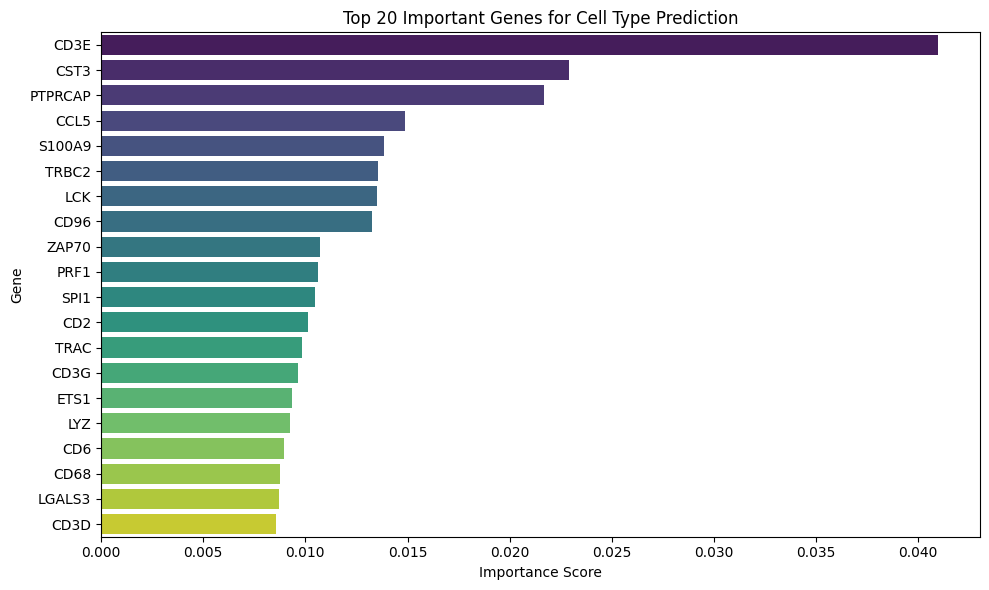

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

train = pyreadr.read_r("train.rds")[None]
train.columns = train.columns.str.replace('[- ]', '_', regex=True)

# Split features and labels
X = train.drop(['SampleID', 'CellType'], axis=1)
y = train['CellType']
    
# Create validation split 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# Get feature importances
importances = pd.DataFrame({
    'Gene': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Gene', data=importances, palette='viridis')
plt.title('Top 20 Important Genes for Cell Type Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

In [ ]:
# Visualizing top 20 biomarker genes for cell type classification
# CD3E and CST3 show highest importance, suggesting strong T-cell and myeloid markers  
# Lower-scoring genes (CD3D, LGALS3) may still contribute to minority class prediction

[0]	validation_0-mlogloss:1.10790
[10]	validation_0-mlogloss:0.14725
[20]	validation_0-mlogloss:0.09395
[30]	validation_0-mlogloss:0.08715
[40]	validation_0-mlogloss:0.08763
[50]	validation_0-mlogloss:0.08765


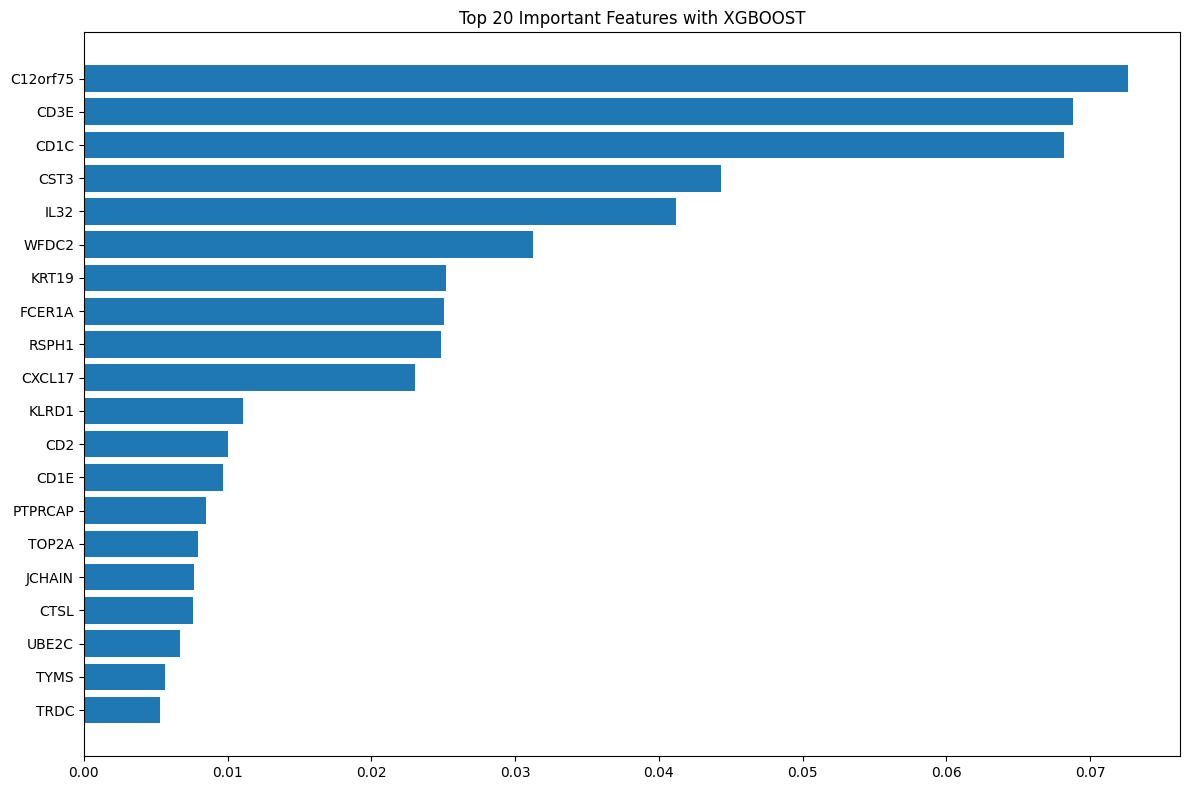


=== Enhanced Evaluation ===
Accuracy: 0.973
Macro F1: 0.892
Weighted F1: 0.972

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.92      0.96        90
         2.0       0.98      0.99      0.99      4954
         3.0       0.90      0.69      0.78       166
         4.0       0.85      0.56      0.68        78
         5.0       1.00      0.69      0.82        13
         6.0       1.00      1.00      1.00         4
         7.0       0.97      0.97      0.97       740
         8.0       0.90      0.89      0.90       112
         9.0       0.92      0.92      0.92        13
        10.0       0.94      0.88      0.91        33

    accuracy                           0.97      6203
   macro avg       0.94      0.85      0.89      6203
weighted avg       0.97      0.97      0.97      6203



In [18]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# 1. Load and prepare data with enhanced cleaning
def load_data(train_path="train.rds"):
    train_data = pyreadr.read_r(train_path)[None]
    train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
    
    # Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.01)
    X = selector.fit_transform(train_data.drop(['SampleID', 'CellType'], axis=1))
    X = pd.DataFrame(X, columns=train_data.drop(['SampleID', 'CellType'], axis=1).columns[selector.get_support()])
    
    y = train_data['CellType']
    return X, y

X, y = load_data()

# 2. Encode labels and split data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 3. Hyperparameter tuning with cross-validation
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=500,
    early_stopping_rounds=20,
    random_state=42
)

# 4. Train with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)

# 5. Feature importance visualization
plt.figure(figsize=(12, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx][-20:], xgb_model.feature_importances_[sorted_idx][-20:])
plt.title("Top 20 Important Features with XGBOOST")
plt.tight_layout()
plt.show()

# 6. Enhanced evaluation
val_preds = xgb_model.predict(X_val)
val_probs = xgb_model.predict_proba(X_val)

print("\n=== Enhanced Evaluation ===")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.3f}")
print(f"Macro F1: {f1_score(y_val, val_preds, average='macro'):.3f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.3f}")

print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))


In [ ]:
# Top features show strong immune cell markers (CD3E, CD2 for T-cells; CST3 for myeloid)
# High accuracy (97.3%) but minority classes (4.0,5.0) still show recall <70%
# Macro F1 (0.89) reveals class imbalance - consider targeted oversampling
# CD1C/CD1E suggest dendritic cell involvement in predictions
# TOP2A/UBE2C indicate proliferating cell populations

[0]	validation_0-mlogloss:1.10790
[10]	validation_0-mlogloss:0.14725
[20]	validation_0-mlogloss:0.09395
[30]	validation_0-mlogloss:0.08715
[40]	validation_0-mlogloss:0.08763
[50]	validation_0-mlogloss:0.08765


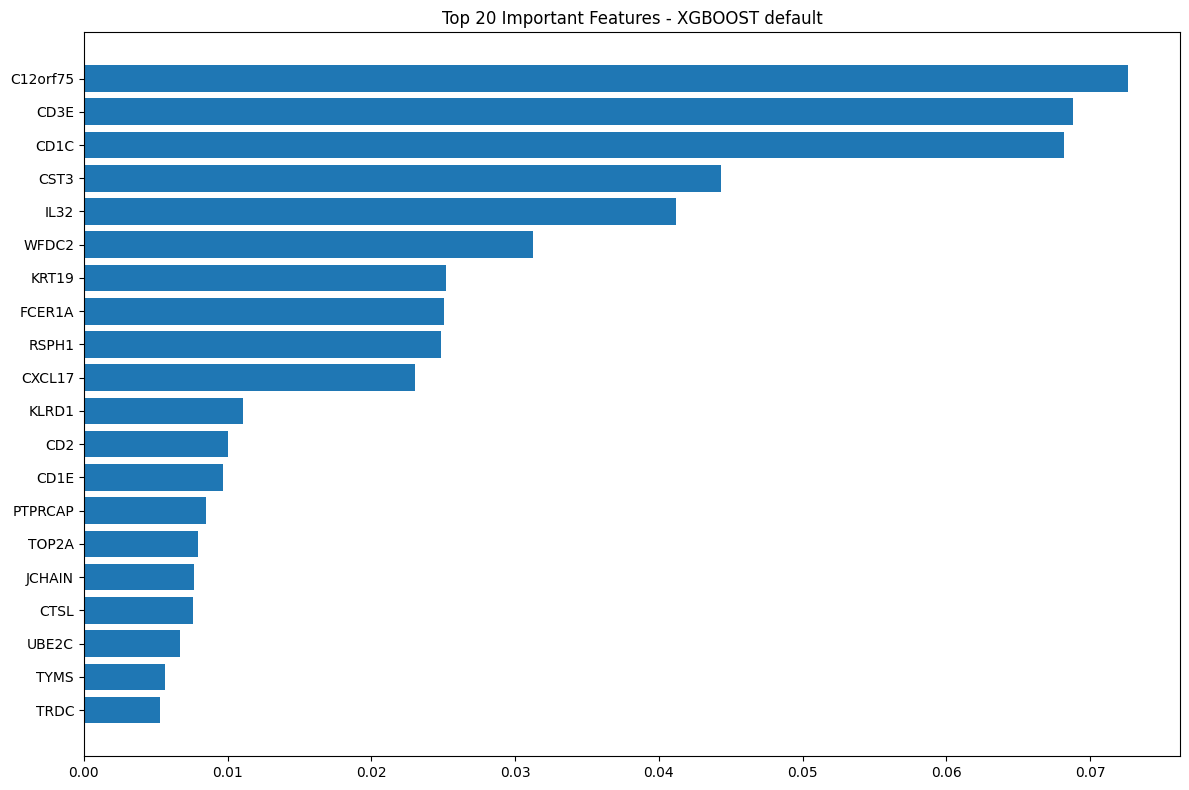


=== Enhanced Evaluation ===
Accuracy: 0.973
Macro F1: 0.892
Weighted F1: 0.972

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.92      0.96        90
         2.0       0.98      0.99      0.99      4954
         3.0       0.90      0.69      0.78       166
         4.0       0.85      0.56      0.68        78
         5.0       1.00      0.69      0.82        13
         6.0       1.00      1.00      1.00         4
         7.0       0.97      0.97      0.97       740
         8.0       0.90      0.89      0.90       112
         9.0       0.92      0.92      0.92        13
        10.0       0.94      0.88      0.91        33

    accuracy                           0.97      6203
   macro avg       0.94      0.85      0.89      6203
weighted avg       0.97      0.97      0.97      6203



In [19]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# 1. Load and prepare data with enhanced cleaning
def load_data(train_path="train.rds"):
    train_data = pyreadr.read_r(train_path)[None]
    train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
    
    # Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.01)
    X = selector.fit_transform(train_data.drop(['SampleID', 'CellType'], axis=1))
    X = pd.DataFrame(X, columns=train_data.drop(['SampleID', 'CellType'], axis=1).columns[selector.get_support()])
    
    y = train_data['CellType']
    return X, y

X, y = load_data()

# 2. Encode labels and split data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 3. Hyperparameter tuning with cross-validation
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=500,
    early_stopping_rounds=20,
    random_state=42
)

# 4. Train with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)

# 5. Feature importance visualization
plt.figure(figsize=(12, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx][-20:], xgb_model.feature_importances_[sorted_idx][-20:])
plt.title("Top 20 Important Features - XGBOOST default")
plt.tight_layout()
plt.show()

# 6. Enhanced evaluation
val_preds = xgb_model.predict(X_val)
val_probs = xgb_model.predict_proba(X_val)

print("\n=== Enhanced Evaluation ===")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.3f}")
print(f"Macro F1: {f1_score(y_val, val_preds, average='macro'):.3f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.3f}")

print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))

[0]	validation_0-mlogloss:1.38015
[10]	validation_0-mlogloss:0.29157
[20]	validation_0-mlogloss:0.14786
[30]	validation_0-mlogloss:0.10782
[40]	validation_0-mlogloss:0.09599
[50]	validation_0-mlogloss:0.09051
[60]	validation_0-mlogloss:0.08772
[70]	validation_0-mlogloss:0.08704
[80]	validation_0-mlogloss:0.08694
[90]	validation_0-mlogloss:0.08693
[95]	validation_0-mlogloss:0.08699


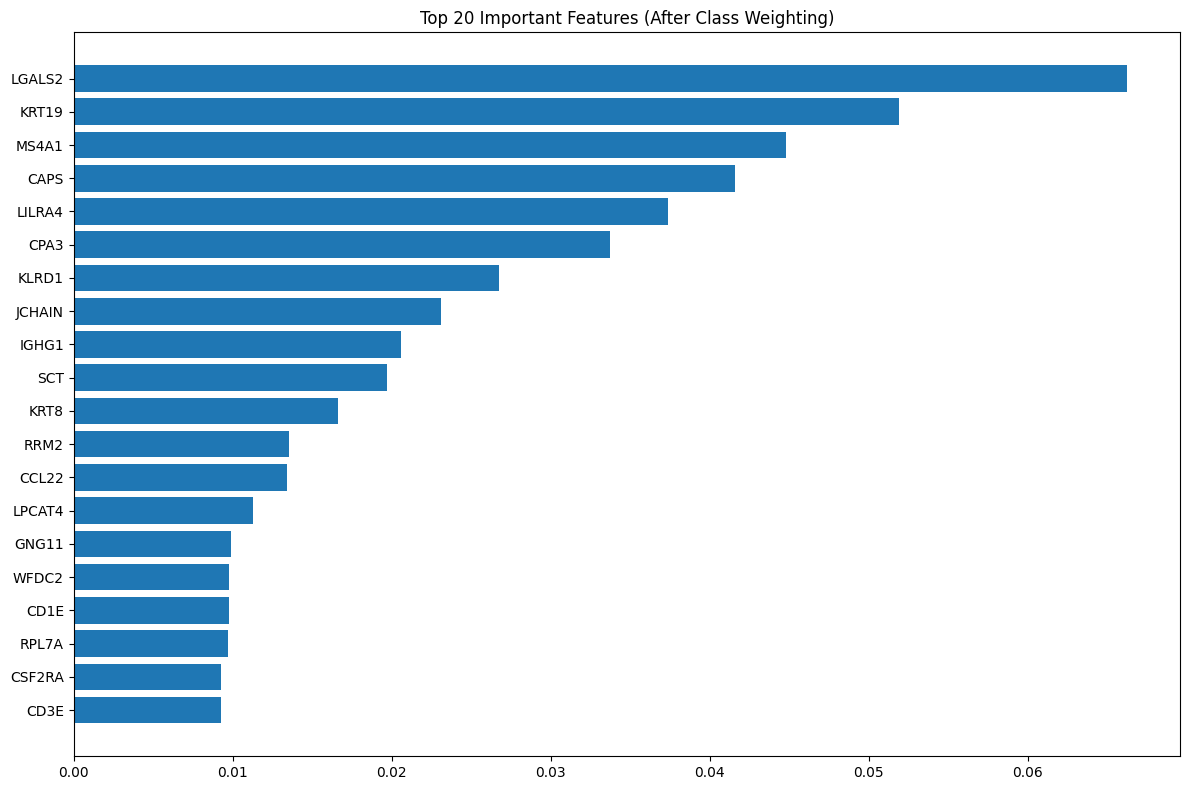


=== Enhanced Evaluation (With Class Weighting) ===
Accuracy: 0.976
Macro F1: 0.889
Weighted F1: 0.976

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.97      0.98        90
         2.0       0.99      0.99      0.99      4954
         3.0       0.82      0.84      0.83       166
         4.0       0.75      0.67      0.71        78
         5.0       1.00      0.85      0.92        13
         6.0       0.67      1.00      0.80         4
         7.0       0.97      0.97      0.97       740
         8.0       0.87      0.91      0.89       112
         9.0       0.86      0.92      0.89        13
        10.0       0.94      0.88      0.91        33

    accuracy                           0.98      6203
   macro avg       0.89      0.90      0.89      6203
weighted avg       0.98      0.98      0.98      6203



In [4]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# 1. Load and prepare data
def load_data(train_path="train.rds"):
    train_data = pyreadr.read_r(train_path)[None]
    train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
    
    # Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.01)
    X = selector.fit_transform(train_data.drop(['SampleID', 'CellType'], axis=1))
    X = pd.DataFrame(X, columns=train_data.drop(['SampleID', 'CellType'], axis=1).columns[selector.get_support()])
    
    y = train_data['CellType']
    return X, y

X, y = load_data()

# 2. Encode labels and split data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 3. Calculate class weights (key improvement for imbalance)
class_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 4. Train XGBoost with class weights
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=500,
    early_stopping_rounds=20,
    random_state=42,
    tree_method='hist',  # Faster training
    enable_categorical=False
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=class_weights,  # Critical for imbalance
    eval_set=[(X_val, y_val)],
    verbose=10
)

# 5. Feature importance visualization
plt.figure(figsize=(12, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx][-20:], xgb_model.feature_importances_[sorted_idx][-20:])
plt.title("Top 20 Important Features (After Class Weighting)")
plt.tight_layout()
plt.show()

# 6. Enhanced evaluation
val_preds = xgb_model.predict(X_val)

print("\n=== Enhanced Evaluation (With Class Weighting) ===")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.3f}")
print(f"Macro F1: {f1_score(y_val, val_preds, average='macro'):.3f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.3f}")

print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))

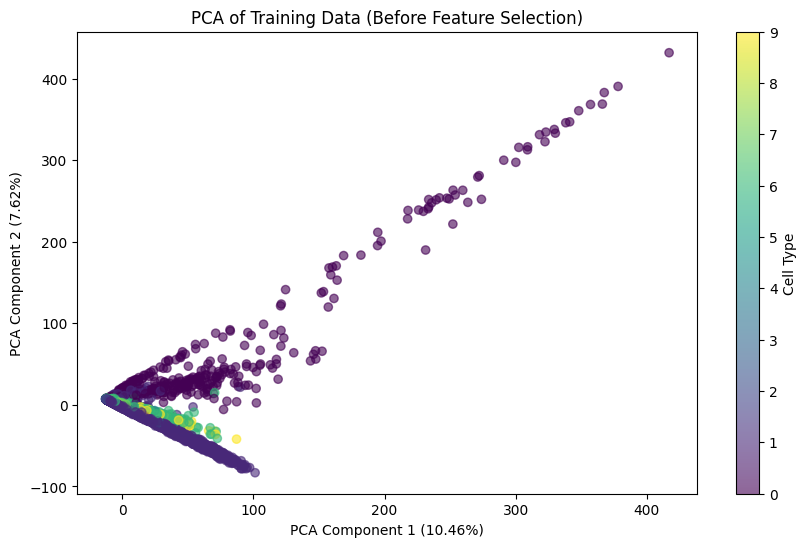

[0]	validation_0-mlogloss:1.38015
[10]	validation_0-mlogloss:0.29157
[20]	validation_0-mlogloss:0.14786
[30]	validation_0-mlogloss:0.10782
[40]	validation_0-mlogloss:0.09599
[50]	validation_0-mlogloss:0.09051
[60]	validation_0-mlogloss:0.08772
[70]	validation_0-mlogloss:0.08704
[80]	validation_0-mlogloss:0.08694
[90]	validation_0-mlogloss:0.08693
[96]	validation_0-mlogloss:0.08711

=== Evaluation ===
              precision    recall  f1-score   support

         1.0       1.00      0.97      0.98        90
         2.0       0.99      0.99      0.99      4954
         3.0       0.82      0.84      0.83       166
         4.0       0.75      0.67      0.71        78
         5.0       1.00      0.85      0.92        13
         6.0       0.67      1.00      0.80         4
         7.0       0.97      0.97      0.97       740
         8.0       0.87      0.91      0.89       112
         9.0       0.86      0.92      0.89        13
        10.0       0.94      0.88      0.91        33



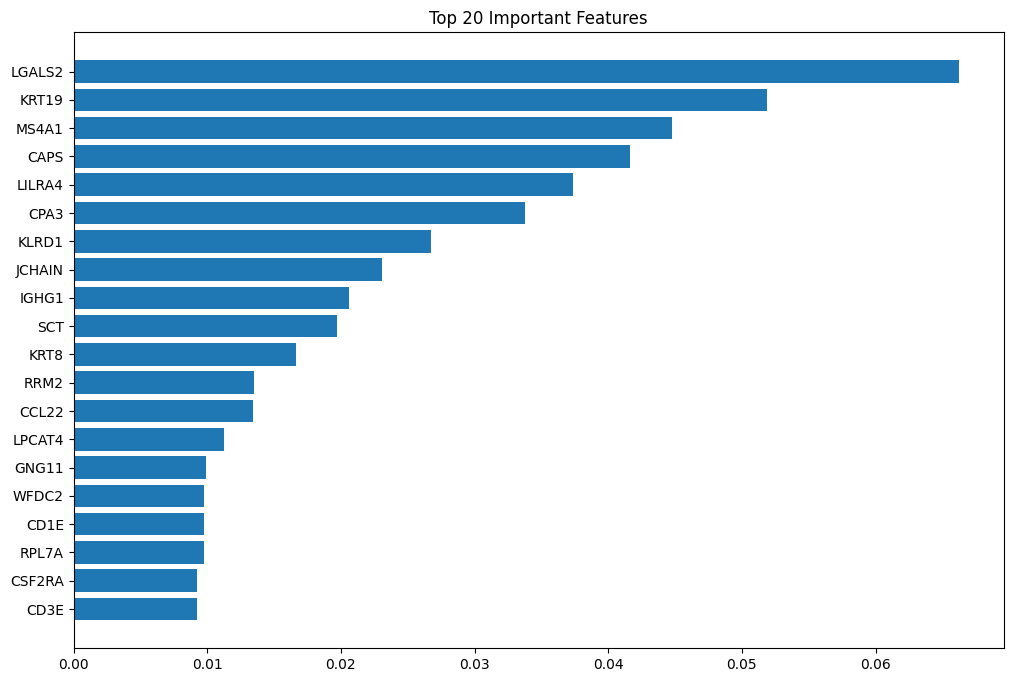

In [5]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# 1. Load and prepare data
def load_data(train_path="train.rds"):
    train_data = pyreadr.read_r(train_path)[None]
    train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
    
    # Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.01)
    X = selector.fit_transform(train_data.drop(['SampleID', 'CellType'], axis=1))
    X = pd.DataFrame(X, columns=train_data.drop(['SampleID', 'CellType'], axis=1).columns[selector.get_support()])
    
    y = train_data['CellType']
    return X, y

X, y = load_data()

# 2. Encode labels and split data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 3. PCA Visualization (Key Addition)
def plot_pca(X, y, title):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.6, cmap='viridis')
    plt.colorbar(scatter, label='Cell Type')
    plt.xlabel('PCA Component 1 (%.2f%%)' % (pca.explained_variance_ratio_[0] * 100))
    plt.ylabel('PCA Component 2 (%.2f%%)' % (pca.explained_variance_ratio_[1] * 100))
    plt.title(title)
    plt.show()

plot_pca(X_train, y_train, "PCA of Training Data (Before Feature Selection)")

# 4. Class weights for imbalance
class_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 5. Train XGBoost (same as before)
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    n_estimators=500,
    early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=class_weights,
    eval_set=[(X_val, y_val)],
    verbose=10
)

# 6. Evaluate
val_preds = xgb_model.predict(X_val)
print("\n=== Evaluation ===")
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))

# 7. Feature Importance (compare with PCA)
plt.figure(figsize=(12, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx][-20:], xgb_model.feature_importances_[sorted_idx][-20:])
plt.title("Top 20 Important Features")
plt.show()


Class distribution after targeted SMOTE:
1    19812
6     2960
2      664
7      447
0      359
3      311
4      208
9      133
5       68
8       53
Name: count, dtype: int64


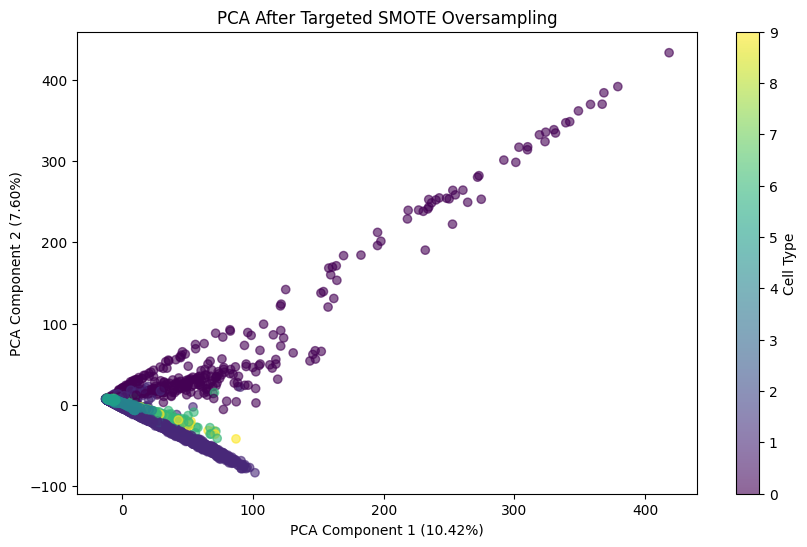

[0]	validation_0-mlogloss:1.37411
[10]	validation_0-mlogloss:0.29006
[20]	validation_0-mlogloss:0.14871
[30]	validation_0-mlogloss:0.10986
[40]	validation_0-mlogloss:0.09702
[50]	validation_0-mlogloss:0.09090
[60]	validation_0-mlogloss:0.08890
[70]	validation_0-mlogloss:0.08787
[80]	validation_0-mlogloss:0.08756
[90]	validation_0-mlogloss:0.08750
[100]	validation_0-mlogloss:0.08769
[106]	validation_0-mlogloss:0.08798

=== Evaluation After Targeted SMOTE ===
              precision    recall  f1-score   support

         1.0       1.00      0.97      0.98        90
         2.0       0.99      0.99      0.99      4954
         3.0       0.86      0.86      0.86       166
         4.0       0.78      0.65      0.71        78
         5.0       1.00      0.85      0.92        13
         6.0       0.80      1.00      0.89         4
         7.0       0.97      0.98      0.97       740
         8.0       0.87      0.91      0.89       112
         9.0       0.92      0.92      0.92        

In [11]:
# 3.5 Apply SMOTE only to minority classes (before PCA visualization)
from imblearn.over_sampling import SMOTE
from collections import Counter

# Identify minority classes (e.g., recall < 80% in your classification report)
minority_classes = [4, 5]  # Update based on your label_encoder mapping (Class 4.0, 5.0)
minority_mask = np.isin(y_train, minority_classes)

# Apply SMOTE only to minority classes (2x oversampling)
smote = SMOTE(sampling_strategy={cls: 2 * np.sum(y_train == cls) for cls in minority_classes}, 
              random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train[minority_mask], 
    y_train[minority_mask]
)

# Combine back with original majority classes
X_train_balanced = np.vstack([X_train[~minority_mask], X_train_smote])
y_train_balanced = np.hstack([y_train[~minority_mask], y_train_smote])

# Verify new class distribution
print("\nClass distribution after targeted SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# Update training set for downstream steps
X_train = pd.DataFrame(X_train_balanced, columns=X.columns)
y_train = y_train_balanced

# Proceed with PCA visualization (now shows balanced data)
plot_pca(X_train, y_train, "PCA After Targeted SMOTE Oversampling")

# 4. Recompute class weights for balanced data
class_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 5. Retrain XGBoost (rest of your code remains identical)
xgb_model.fit(
    X_train, y_train,
    sample_weight=class_weights,
    eval_set=[(X_val, y_val)],
    verbose=10
)

# 6. Evaluate
val_preds = xgb_model.predict(X_val)
print("\n=== Evaluation After Targeted SMOTE ===")
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))

print("\n=== Enhanced Evaluation (With Class Weighting) ===")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.3f}")
print(f"Macro F1: {f1_score(y_val, val_preds, average='macro'):.3f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.3f}")

In [13]:
# added smote increased accuracy to 0.977, major improvementin in class 4 and 6 

In [ ]:
# tried random forest + xgboost however it reduced accuracy to 0.93, tried logistiv + xg however we say no improvemetns while accuracy was at 0.96 